<a href="https://colab.research.google.com/github/Sanchithedau/Data_Science_Lab_SE_A_18/blob/main/Experiment%209/sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
mohammadtalib786_retail_sales_dataset_path = kagglehub.dataset_download('mohammadtalib786/retail-sales-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/mohammadtalib786/retail-sales-dataset/retail_sales_dataset.csv')

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

total_sales = df['Total Amount'].sum()
total_units = df['Quantity'].sum()

print("Total Sales:", total_sales)
print("Total Units Sold:", total_units)

Total Sales: 456000
Total Units Sold: 2514


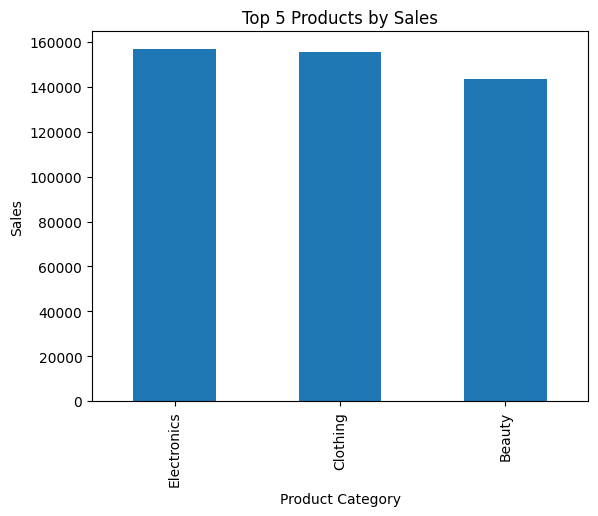

In [ ]:
import matplotlib.pyplot as plt

top_products = df.groupby('Product Category')['Total Amount'].sum().nlargest(5)

top_products.plot(kind='bar')
plt.title('Top 5 Products by Sales')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.show()

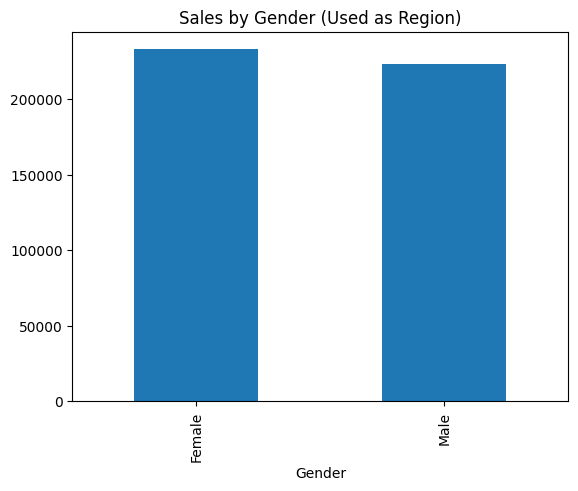

In [ ]:
region_sales = df.groupby('Gender')['Total Amount'].sum()

region_sales.plot(kind='bar')
plt.title('Sales by Gender (Used as Region)')
plt.show()

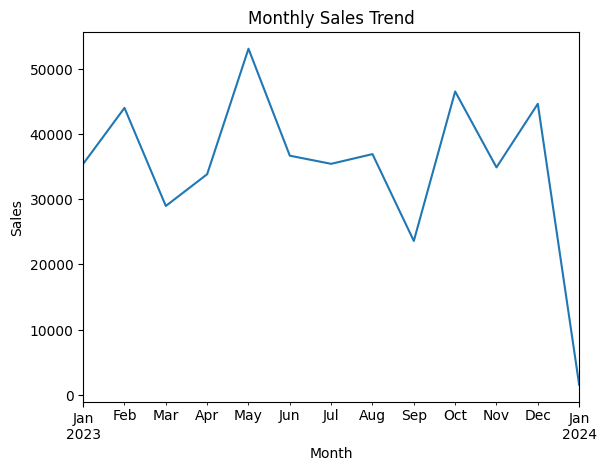

In [ ]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [ ]:
fig = px.scatter(
    df,
    x='Quantity',
    y='Total Amount',
    color='Product Category',
    size='Total Amount',
    hover_data=['Price per Unit', 'Age'],
    title='Sales Analysis Scatter Plot'
)

fig.show()